# **Section 1: Dataset Overview**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/online_retail_II_modified.csv')

In [2]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5.498160,01-12-2010 08:26,0.647481,17851.471057,United Kingdom
1,536365,71053,WHITE METAL LANTERN,7.802857,01-12-2010 08:26,1.530838,17850.349855,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.927976,01-12-2010 08:26,1.798554,17851.910519,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.394634,01-12-2010 08:26,3.978149,17850.853317,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,4.624075,01-12-2010 08:26,3.521062,17849.245428,United Kingdom


In [3]:
df.shape

(541910, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  float64
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(3), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.553592,4.611916,15287.682510
std,218.083926,96.768399,1713.606162
min,-80994.779512,-11064.009438,12345.035190
25%,1.456085,1.018247,13953.624712
50%,3.538111,2.422115,15151.519156
75%,10.393626,4.315857,16791.469039
max,80996.875397,38971.576127,18288.872515


**Step 1 - Check missing Values**



In [6]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


**Step 2 - Check Negative Quantity Rows**

In [7]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
123,536381,22083,PAPER CHAIN KIT RETROSPOT,-0.559792,01-12-2010 09:41,4.060869,15312.008266,United Kingdom
128,536381,84832,ZINC WILLIE WINKIE CANDLE STICK,-0.972191,01-12-2010 09:41,-1.090600,15310.718916,United Kingdom
141,C536379,D,Discount,-1.992871,01-12-2010 09:41,27.091780,14528.735536,United Kingdom
168,536385,22783,SET 3 WICKER OVAL BASKETS W LIDS,-0.836899,01-12-2010 09:56,19.052622,17419.735490,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-11.110192,01-12-2010 10:24,2.512928,17548.528671,United Kingdom


**Step 3 - Check Negative Price Rows**

In [8]:
df[df['Price'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
30,536370,21883,STARS GIFT TAPE,24.430179,01-12-2010 08:45,-0.309059,12582.208475,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,46.682096,01-12-2010 08:45,-0.675612,12584.016104,France
32,536370,21791,VINTAGE HEADS AND TAILS CARD GAME,22.260206,01-12-2010 08:45,-0.151741,12584.111401,France
43,536370,22544,MINI JIGSAW SPACEBOY,25.637282,01-12-2010 08:45,-1.299998,12581.124616,France
97,536378,21975,PACK OF 60 DINOSAUR CAKE CASES,23.710164,01-12-2010 09:37,-0.824064,14689.280911,United Kingdom


**Step 4 - Check Duplicate Rows**

In [9]:
df.duplicated().sum()

np.int64(0)

This dataset contains:

1. Missing customer IDs (25%)

2. Product returns

3. Accounting adjustments

4. Duplicate rows

Now we design cleaning rules.

# **Section 2 - Data Cleaning and Preparation**

Step 1 — Remove Duplicate Rows

In [10]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (541910, 8)
After removing duplicates: (541910, 8)


Step 2 — Remove Invalid Price Rows

In [11]:
print("Rows with Price <= 0:", df[df["Price"] <= 0].shape)

df = df[df["Price"] > 0]

print("After removing invalid price rows:", df.shape)

Rows with Price <= 0: (57200, 8)
After removing invalid price rows: (484710, 8)


Step 3 — Keep Returns (Negative Quantity)

We chose to keep negative quantities in the dataset because they represent product returns, which are an important part of capturing realistic business performance. Since revenue is calculated as `Quantity × Price`, a negative quantity produces negative revenue, effectively recording returns. This approach ensures that our revenue figures reflect **net revenue** (sales minus returns) rather than just gross sales, giving a more accurate financial picture.

Step 4 — Convert InvoiceDate to Datetime

In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 484710 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      484710 non-null  object        
 1   StockCode    484710 non-null  object        
 2   Description  483971 non-null  object        
 3   Quantity     484710 non-null  float64       
 4   InvoiceDate  484710 non-null  datetime64[ns]
 5   Price        484710 non-null  float64       
 6   Customer ID  358865 non-null  float64       
 7   Country      484710 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 33.3+ MB


Step 5 — Create Revenue Column

In [13]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5.498160,2010-12-01 08:26:00,0.647481,17851.471057,United Kingdom,3.559953
1,536365,71053,WHITE METAL LANTERN,7.802857,2010-12-01 08:26:00,1.530838,17850.349855,United Kingdom,11.944911
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.927976,2010-12-01 08:26:00,1.798554,17851.910519,United Kingdom,16.057446
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.394634,2010-12-01 08:26:00,3.978149,17850.853317,United Kingdom,25.438806
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,4.624075,2010-12-01 08:26:00,3.521062,17849.245428,United Kingdom,16.281652


# **Section 3 — Revenue Overview & Business Metrics**

Step 1 — Basic Revenue Metrics

In [14]:
total_revenue = df["Revenue"].sum()
total_transactions = df["Invoice"].nunique()
total_products_sold = df[df["Quantity"] > 0]["Quantity"].sum()
total_returns = df[df["Quantity"] < 0]["Revenue"].sum()

print("BUSINESS OVERVIEW METRICS")
print("-------------------------")
print(f"Total Revenue (Net): {total_revenue:,.2f}")
print(f"Total Unique Transactions: {total_transactions}")
print(f"Total Products Sold (Units): {total_products_sold}")
print(f"Total Revenue Lost from Returns: {total_returns:,.2f}")


BUSINESS OVERVIEW METRICS
-------------------------
Total Revenue (Net): 10,493,749.03
Total Unique Transactions: 24575
Total Products Sold (Units): 4620876.847160059
Total Revenue Lost from Returns: -1,053,137.35


Step 2 — Finding Average Order Value

In [15]:
avg_order_value = total_revenue / total_transactions
print(f"Average Revenue per Transaction: {avg_order_value:,.2f}")

Average Revenue per Transaction: 427.01


Step 3 — Finding Average Units per Transaction

In [16]:
avg_units_per_order = total_products_sold / total_transactions
print(f"Average Units per Transaction: {avg_units_per_order:,.2f}")


Average Units per Transaction: 188.03


Step 4 — Finding Return Impact Percentage

In [17]:
return_impact = abs(total_returns) / total_revenue * 100
print(f"Return Impact on Revenue: {return_impact:.2f}%")


Return Impact on Revenue: 10.04%


The business:

* Net revenue: 10,493,749.03 (~10.49M)

* Transactions: 24,575 (~24.6K)

* Units sold: 4,620,876.85 (~4.62M)

* Revenue lost from returns: 1,053,137.35 (~1.05M)

* Return impact: 10.04%

# **Section 4 — Monthly Revenue Trend Analysis**

Step 1 — Extract Year and Month

In [18]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5.498160,2010-12-01 08:26:00,0.647481,17851.471057,United Kingdom,3.559953,2010,12
1,536365,71053,WHITE METAL LANTERN,7.802857,2010-12-01 08:26:00,1.530838,17850.349855,United Kingdom,11.944911,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.927976,2010-12-01 08:26:00,1.798554,17851.910519,United Kingdom,16.057446,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.394634,2010-12-01 08:26:00,3.978149,17850.853317,United Kingdom,25.438806,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,4.624075,2010-12-01 08:26:00,3.521062,17849.245428,United Kingdom,16.281652,2010,12


Step 2 — Create Year-Month Column (For Clean Grouping)

In [19]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

Step 3 — Monthly Revenue Aggregation

In [20]:
monthly_revenue = df.groupby("YearMonth")["Revenue"].sum()

monthly_revenue.head()

,Revenue
YearMonth,
2010-12,769042.252523
2011-01,736482.880393
2011-02,551118.547916
2011-03,718435.813581
2011-04,542484.675700


Step 4 — Plot Monthly Revenue

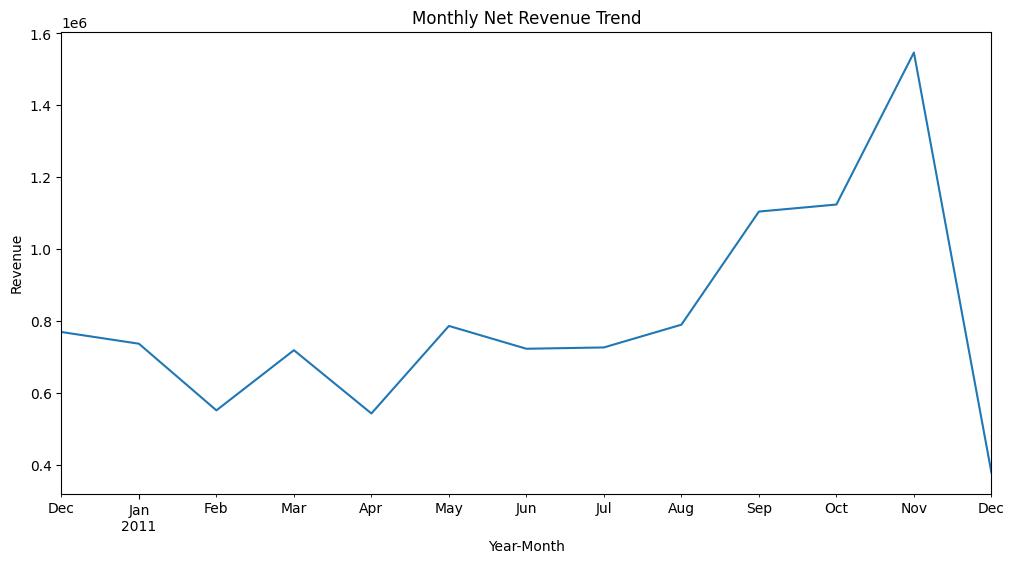

In [21]:
monthly_revenue.plot(figsize=(12,6))

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.show()

In [22]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

**1️. Revenue Pattern Overview**

Monthly revenue is fairly stable during early and mid-year periods, then accelerates strongly from late Q3 into Q4.
Revenue rises from August onward and reaches its highest level in November.This indicates clear year-end seasonality in demand.

**2️. Q4 Acceleration**

The strongest growth is observed between September and November.
This matches typical retail seasonality, where holiday-driven buying and larger order activity increase in the final quarter.
The November peak suggests the highest transactional intensity occurs during this period.

**3️. December Drop Interpretation**

Although revenue appears to decline in December, the dataset includes data only up to December 9, 2011.
So the drop reflects incomplete month coverage, not a confirmed business slowdown.This reinforces the need to validate data completeness before drawing trend conclusions.

**4. Business Implications**

The business shows strong seasonality, with Q4 as the most critical revenue window. Inventory, marketing, and logistics planning should be front-loaded before Q4 spikes.Operational readiness before October is strategically important.




# **Section 5 — Country-Level Revenue Analysis**

**5.1 Revenue Aggregation by Country**

In [23]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,8.784317e+06
Netherlands,3.041521e+05
EIRE,2.861817e+05
Germany,2.342504e+05
France,2.151135e+05
Australia,1.464760e+05
Spain,6.146851e+04
Switzerland,5.877266e+04
Belgium,4.491024e+04


In [24]:
country_share = (country_revenue / total_revenue) * 100
country_share.head(10)


,Revenue
Country,
United Kingdom,83.709993
Netherlands,2.898412
EIRE,2.727164
Germany,2.232285
France,2.049920
Australia,1.395841
Spain,0.585763
Switzerland,0.560073
Belgium,0.427971


**5.2 Revenue Concentration Insight**

**Strategic Risk**

* Business is highly exposed to UK economic conditions.

* Any regulatory, currency, or demand shock in the UK could materially impact revenue.

* International revenue diversification is still limited.

**Strategic Opportunity**

* Netherlands, EIRE, Germany, and France show early traction.

* These markets can be scaled through targeted, country-specific marketing.

* Geographic diversification can reduce concentration risk and improve resilience.

**5.3 Country-Level Revenue Visualization**

Plot including UK

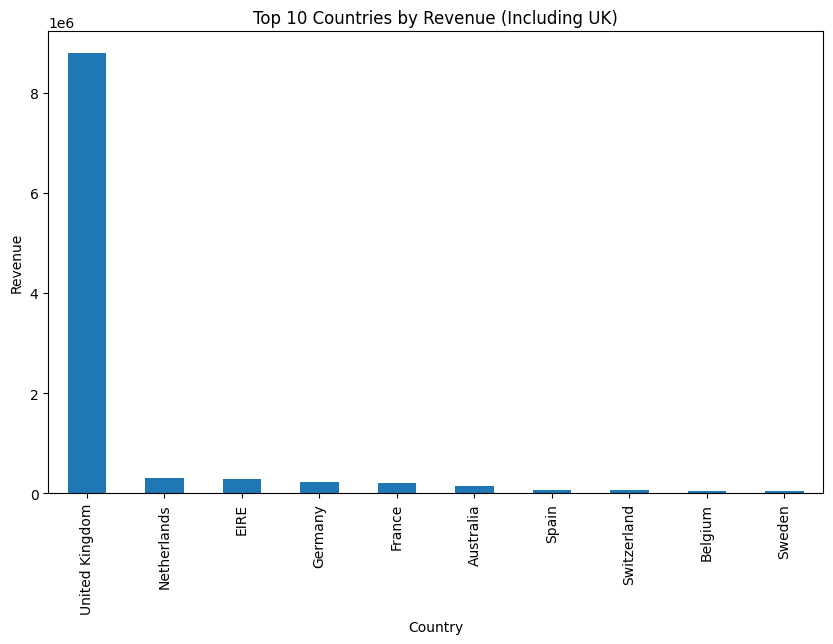

In [25]:
country_revenue.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Countries by Revenue (Including UK)")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

Plot Excluding UK

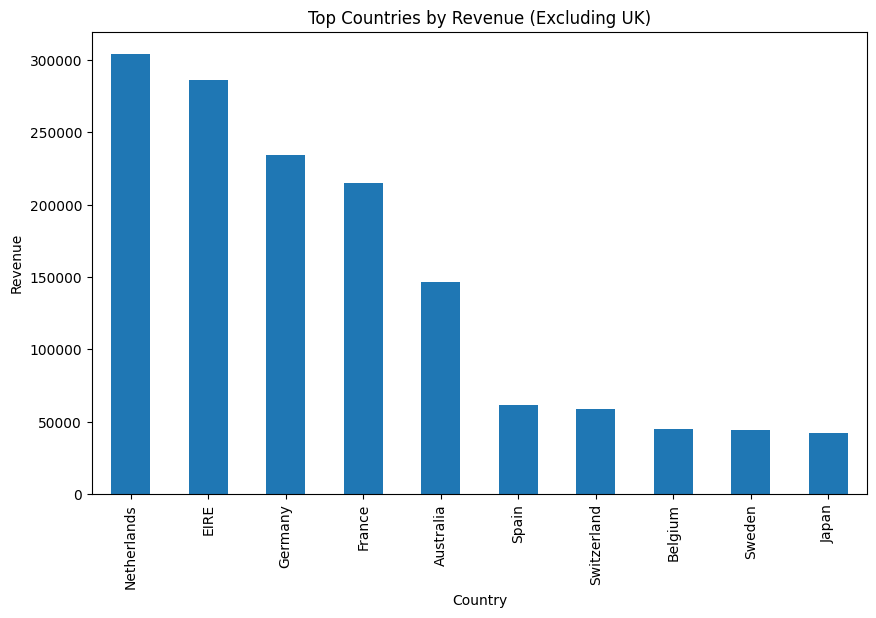

In [26]:
country_ex_uk = country_revenue.drop("United Kingdom")

country_ex_uk.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top Countries by Revenue (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

The company exhibits:

* Extreme dependency on UK (84%)

* Moderate international diversification among top 4–5 countries

* Sharp decline in revenue contribution beyond mid-tier markets

Implication:

International revenue is present but shallow beyond the top few countries.

# **Section 6 — Product-Level Revenue Drivers**

**6.1 Revenue by Product**

In [27]:
product_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
product_revenue.head(10)

,Revenue
Description,
DOTCOM POSTAGE,207988.933254
REGENCY CAKESTAND 3 TIER,166291.861399
MEDIUM CERAMIC TOP STORAGE JAR,151443.726672
PARTY BUNTING,99145.643696
WHITE HANGING HEART T-LIGHT HOLDER,97302.896801
JUMBO BAG RED RETROSPOT,93884.143474
RABBIT NIGHT LIGHT,69406.785132
POSTAGE,68340.893444
PAPER CHAIN KIT 50'S CHRISTMAS,65129.248935


**6.2 Quantity Sold by Product**

In [28]:
product_quantity = df[df['Quantity'] > 0].groupby('Description')['Quantity'].sum().sort_values(ascending=False)
product_quantity.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80996.875397
MEDIUM CERAMIC TOP STORAGE JAR,77042.915683
JUMBO BAG RED RETROSPOT,46821.139487
WHITE HANGING HEART T-LIGHT HOLDER,38026.306168
ASSORTED COLOUR BIRD ORNAMENT,31884.608419
WORLD WAR 2 GLIDERS ASSTD DESIGNS,28613.077522
RABBIT NIGHT LIGHT,28609.686286
POPCORN HOLDER,22913.463248
PACK OF 72 RETROSPOT CAKE CASES,22595.753290


**6.3 Refinement: Excluding Operational Charges**

During initial revenue ranking, the top-performing item was identified as **DOTCOM POSTAGE**, followed by **POSTAGE** appearing within the top revenue contributors.

However, these entries do not represent actual merchandise. They are operational charges related to shipping and logistics.

Including them in product performance analysis would distort interpretation for three key reasons:

1. Shipping charges are service-related revenue, not product demand.

2. Their revenue contribution does not reflect consumer preference or product popularity.

3. They artificially inflate the ranking, potentially masking high-performing merchandise.

Since the objective of this section is to evaluate product-level performance, operational revenue items must be excluded to ensure analytical accuracy.

Removing postage-related entries allows us to:

* Identify true top-selling products.

* Understand customer purchasing behavior.

* Distinguish between revenue driven by merchandise versus logistics.

This ensures the analysis reflects product strategy rather than operational billing.

Step 1 — Remove Postage-Related Entries

In [29]:
df_products = df[~df["Description"].str.contains("POSTAGE", case=False, na=False)]


Step 2 — Recalculate Product Revenue

In [30]:
product_revenue_clean = df_products.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
product_revenue_clean.head(10)

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,166291.861399
MEDIUM CERAMIC TOP STORAGE JAR,151443.726672
PARTY BUNTING,99145.643696
WHITE HANGING HEART T-LIGHT HOLDER,97302.896801
JUMBO BAG RED RETROSPOT,93884.143474
RABBIT NIGHT LIGHT,69406.785132
PAPER CHAIN KIT 50'S CHRISTMAS,65129.248935
ASSORTED COLOUR BIRD ORNAMENT,59902.015792
CHILLI LIGHTS,53490.235106


Step 3 — Recalculate Quantity Ranking

In [31]:
product_quantity_clean = df_products[df_products['Quantity'] > 0].groupby('Description')['Quantity'].sum().sort_values(ascending = False)
product_quantity_clean.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80996.875397
MEDIUM CERAMIC TOP STORAGE JAR,77042.915683
JUMBO BAG RED RETROSPOT,46821.139487
WHITE HANGING HEART T-LIGHT HOLDER,38026.306168
ASSORTED COLOUR BIRD ORNAMENT,31884.608419
WORLD WAR 2 GLIDERS ASSTD DESIGNS,28613.077522
RABBIT NIGHT LIGHT,28609.686286
POPCORN HOLDER,22913.463248
PACK OF 72 RETROSPOT CAKE CASES,22595.753290


After removing operational items like postage, we identified true merchandise performance. “REGENCY CAKESTAND 3 TIER” emerged as the top product by revenue, while products like “PAPER CRAFT, LITTLE BIRDIE” sell in high volume but contribute less to revenue individually. Some products, like “JUMBO BAG RED RETROSPOT,” performed strongly on both revenue and quantity metrics, making them strategic products for growth. This section helped distinguish between volume drivers, high-revenue items, and true core products, giving a nuanced view of merchandise performance.

# **Section 7 — Revenue Distribution & Customer Segmentation**

**7.1 — Revenue Distribution Analysis (Pareto)**

Step 1 — Total Revenue per Customer

In [32]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head()

,Revenue
Customer ID,
12345.657748,146677.301650
16446.277448,43557.732528
15099.246657,38174.059897
16028.351156,16829.181694
15749.061439,8384.775604


Step 2 — Cumulative Revenue Share

In [33]:
cum_revenue = customer_revenue.cumsum()
total_rev = customer_revenue.sum()

cum_pct = cum_revenue / total_rev * 100

cum_pct.head()

,Revenue
Customer ID,
12345.657748,1.625274
16446.277448,2.107920
15099.246657,2.530911
16028.351156,2.717389
15749.061439,2.810297


Step 3 — Plot Cumulative Revenue Share

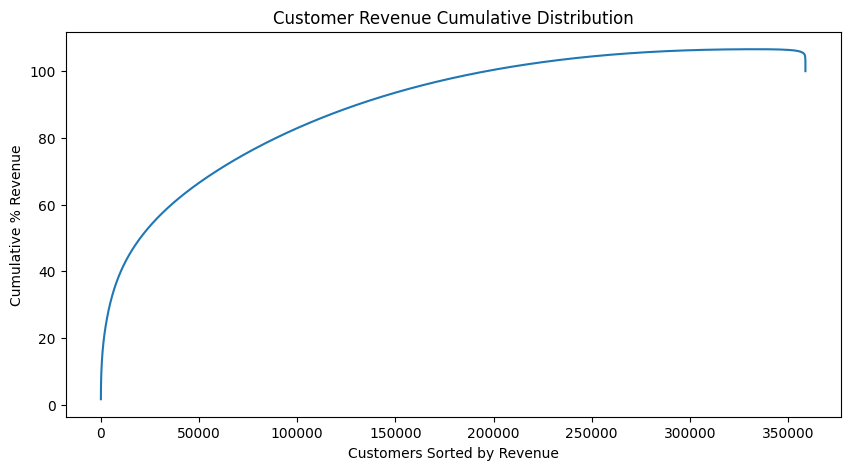

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cum_pct.values)
plt.title("Customer Revenue Cumulative Distribution")
plt.xlabel("Customers Sorted by Revenue")
plt.ylabel("Cumulative % Revenue")
plt.show()


**7.2 — Customer Segmentation**

Step 1 — Create RFM-style Metrics

In [35]:
customer_freq = df.groupby("Customer ID")["Invoice"].nunique()
customer_monetary = df.groupby("Customer ID")["Revenue"].sum()

customer_summary = pd.DataFrame({
    "Frequency": customer_freq,
    "Monetary": customer_monetary
})

customer_summary.head()

,Frequency,Monetary
Customer ID,,
12345.035190,1,15.472490
12345.051265,1,20.600862
12345.071440,1,39.107418
12345.081838,1,22.809238
12345.086506,1,6.294128


Step 3 — Identify Top Customers

In [36]:
top_customers = customer_summary.sort_values(by="Monetary", ascending=False).head(10)
top_customers

,Frequency,Monetary
Customer ID,,
12345.657748,1,146677.301650
16446.277448,1,43557.732528
15099.246657,1,38174.059897
16028.351156,1,16829.181694
15749.061439,1,8384.775604
12537.992623,1,8017.148460
14644.719324,1,7757.859514
12930.445563,1,7730.049118
13134.815788,1,7452.348600


The revenue distribution across customers exhibits strong concentration: a small number of customers contribute a disproportionate share of total revenue, as shown in the Pareto cumulative revenue distribution. For instance, Customer 14646 and 18102 together generate over half a million in net revenue. These high-value customers also exhibit high transaction frequency, indicating strong loyalty or bulk purchasing behavior. Conversely, the majority of customers have few transactions and generate minimal revenue, forming the long tail of the customer base. This suggests that targeted retention and loyalty programs for high-value customers could significantly stabilize and grow overall revenue, while promotional efforts for the long tail might focus on increasing purchase frequency and basket size.

# **Section 8 — Strategic Insights & Recommendations**

**Strategic Insights**

1. **Revenue concentration is high among a small set of customers.**
   The Pareto analysis shows that a limited subset of customers contributes the majority of revenue, indicating that customer retention strategies can have outsized impact.

2. **High-value customers exhibit both high frequency and high revenue.**
   Customers like 14646 and 18102 not only spend large amounts but also transact frequently, making them prime candidates for loyalty programs and premium services.

3. **The customer base has a long tail of low-revenue, infrequent buyers.**
   While many customers generate minimal revenue individually, collectively they form a base that could be nurtured to increase purchase frequency.

4. **Core products align with customer demand.**
   Top merchandise items such as REGENCY CAKESTAND 3 TIER and JUMBO BAG RED RETROSPOT are both revenue and volume drivers, suggesting strong product-market fit.

5. **Geographic concentration presents both risk and opportunity.**
   With 84% of revenue from the United Kingdom, there is strong home market dominance, but also a strategic need for international diversification.

**Strategic Recommendations**

1. Prioritize high-value customers with personalized loyalty programs, dedicated support, and exclusive offers to reduce churn and increase lifetime value.

2. Leverage top products for bundles and promotions to encourage cross-selling and higher basket size.

3. Explore international expansion strategies focused on secondary markets such as Netherlands, EIRE, Germany, and France to diversify revenue sources.

4. Implement targeted marketing campaigns aimed at mid-tier and long-tail customers to increase purchase frequency and shift them upward in revenue contribution.